## **Objective**
The objective of this notebook is to build a Random Forest Classifier that predicts whether a loan application will be approved or rejected based on applicant, income, credit, loan, and property-related information. In the encoded target column, `0` represents a rejected loan application and `1` represents an approved loan application. The model will be evaluated using classification metrics such as accuracy, precision, recall, F1-score, and ROC-AUC. An appropriate primary evaluation metric should be selected according to the problem statement, class distribution, and the importance of different prediction errors. The selected metric will be used as the scoring measure during hyperparameter tuning and for comparing the baseline and tuned models. Training and testing performance will also be compared using the selected metric to identify possible overfitting. The final model will be selected based on its overall performance and ability to generalise well to unseen data.


## **Import Libraries**
- Import the libraries required for data handling, visualisation, model building, tuning, and evaluation

In [1]:
import warnings; warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, ConfusionMatrixDisplay, confusion_matrix, f1_score, precision_score, recall_score, roc_auc_score, roc_curve)
from sklearn.model_selection import GridSearchCV, train_test_split
%matplotlib inline

# **Understanding the Dataset**

## **Task 1**
- Load the loan prediction dataset
- Check the column names and their data types
- Check for missing values

In [2]:
df = pd.read_csv('Loan_Prediction_data.csv'); df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,Yes,1,Graduate,No,4583,1508.0,128,360,1,Rural,N
1,Male,Yes,0,Graduate,Yes,3000,0.0,66,360,1,Urban,Y
2,Male,Yes,0,Not Graduate,No,2583,2358.0,120,360,1,Urban,Y
3,Male,No,0,Graduate,No,6000,0.0,141,360,1,Urban,Y
4,Male,Yes,2,Graduate,Yes,5417,4196.0,267,360,1,Urban,Y


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 480 entries, 0 to 479
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             480 non-null    str    
 1   Married            480 non-null    str    
 2   Dependents         480 non-null    str    
 3   Education          480 non-null    str    
 4   Self_Employed      480 non-null    str    
 5   ApplicantIncome    480 non-null    int64  
 6   CoapplicantIncome  480 non-null    float64
 7   LoanAmount         480 non-null    int64  
 8   Loan_Amount_Term   480 non-null    int64  
 9   Credit_History     480 non-null    int64  
 10  Property_Area      480 non-null    str    
 11  Loan_Status        480 non-null    str    
dtypes: float64(1), int64(4), str(7)
memory usage: 57.6 KB


In [4]:
missing_values = df.isnull().sum(); missing_values

Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

## **Task 2**
- Display the count of approved and rejected loan applications using readable labels
- Visualise the number of approved and rejected applications using a bar plot

In [5]:
loan_status_counts = df['Loan_Status'].map({'N': 'Rejected', 'Y': 'Approved'}).value_counts(); loan_status_counts

Loan_Status
Approved    332
Rejected    148
Name: count, dtype: int64

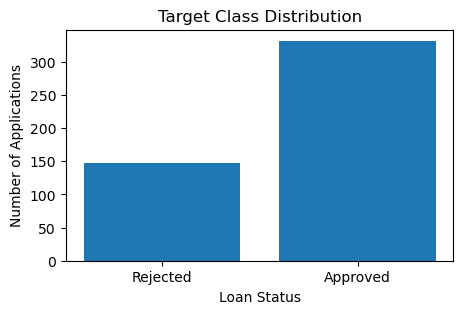

In [6]:
plot_counts = loan_status_counts.reindex(['Rejected', 'Approved'])
plt.figure(figsize = (5, 3))
plt.bar(plot_counts.index, plot_counts.values)
plt.title('Target Class Distribution'); plt.xlabel('Loan Status'); plt.ylabel('Number of Applications')
plt.show()

# **Data Preparation**

## **Task 3**
- Convert the target labels into numerical values

In [7]:
df['Loan_Status'] = df['Loan_Status'].map({'N': 0, 'Y': 1})

## **Task 4**
- Separate the predictor features and target variable
- Create stratified training and testing sets

In [8]:
X = df.drop('Loan_Status', axis = 1); y = df['Loan_Status']
print('Shape of X:', X.shape); print('Shape of y:', y.shape)

Shape of X: (480, 11)
Shape of y: (480,)


In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state = 42, stratify = y)

## **Task 5**
- Encode the categorical training and testing features 

In [10]:
X_train_original = X_train.copy(); X_test_original = X_test.copy()
categorical_columns = X_train.select_dtypes(include = 'object').columns
X_train = pd.get_dummies(X_train, columns = categorical_columns, dtype = int)
X_test = pd.get_dummies(X_test, columns = categorical_columns, dtype = int)
X_test = X_test.reindex(columns = X_train.columns, fill_value = 0)
print('Training set shape:', X_train.shape); print('Testing set shape:', X_test.shape)

Training set shape: (384, 20)
Testing set shape: (96, 20)


# **Model Training**

## **Task 6**
- Train the baseline Random Forest model
- Generate training and testing predictions
- Evaluate the baseline model using confusion matrices, accuracy, precision, recall, F1-score, and ROC-AUC

In [11]:
b_model = RandomForestClassifier(random_state = 42); b_model.fit(X_train, y_train)
b_train_pred = b_model.predict(X_train); b_test_pred = b_model.predict(X_test)
b_train_prob = b_model.predict_proba(X_train)[:, 1]; b_test_prob = b_model.predict_proba(X_test)[:, 1]

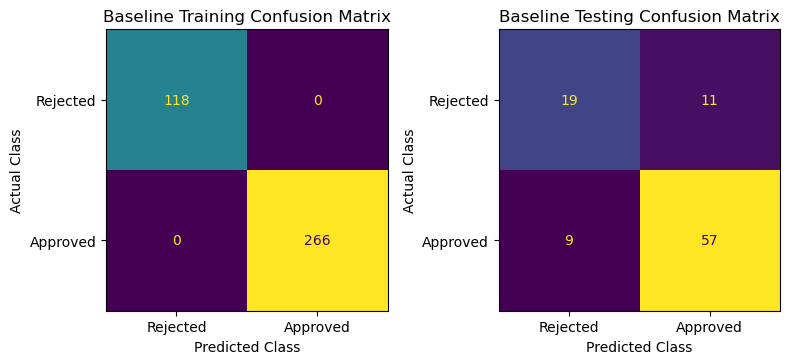

In [12]:
b_train_cm = confusion_matrix(y_train, b_train_pred); b_test_cm = confusion_matrix(y_test, b_test_pred)
fig, axes = plt.subplots(1, 2, figsize=(8, 5))
ConfusionMatrixDisplay(confusion_matrix=b_train_cm, display_labels=['Rejected', 'Approved']).plot(ax=axes[0], colorbar=False)
axes[0].set_title('Baseline Training Confusion Matrix')
axes[0].set_xlabel('Predicted Class'); axes[0].set_ylabel('Actual Class')
ConfusionMatrixDisplay(confusion_matrix=b_test_cm, display_labels=['Rejected', 'Approved']).plot(ax=axes[1], colorbar=False)
axes[1].set_title('Baseline Testing Confusion Matrix')
axes[1].set_xlabel('Predicted Class'); axes[1].set_ylabel('Actual Class')
plt.tight_layout()
plt.show()

In [13]:
b_train_accuracy = accuracy_score(y_train, b_train_pred)
b_train_precision = precision_score(y_train, b_train_pred)
b_train_recall = recall_score(y_train, b_train_pred)
b_train_f1 = f1_score(y_train, b_train_pred)
b_train_roc_auc = roc_auc_score(y_train, b_train_prob)
b_test_accuracy = accuracy_score(y_test, b_test_pred)
b_test_precision = precision_score(y_test, b_test_pred)
b_test_recall = recall_score(y_test, b_test_pred)
b_test_f1 = f1_score(y_test, b_test_pred)
b_test_roc_auc = roc_auc_score(y_test, b_test_prob)

In [14]:
print('Baseline Training Accuracy:', round(b_train_accuracy, 3))
print('Baseline Testing Accuracy:', round(b_test_accuracy, 3))
print('\nBaseline Training Precision:', round(b_train_precision, 3))
print('Baseline Testing Precision:', round(b_test_precision, 3))
print('\nBaseline Training Recall:', round(b_train_recall, 3))
print('Baseline Testing Recall:', round(b_test_recall, 3))
print('\nBaseline Training F1-Score:', round(b_train_f1, 3))
print('Baseline Testing F1-Score:', round(b_test_f1, 3))
print('\nBaseline Training ROC-AUC:', round(b_train_roc_auc, 3))
print('Baseline Testing ROC-AUC:', round(b_test_roc_auc, 3))

Baseline Training Accuracy: 1.0
Baseline Testing Accuracy: 0.792

Baseline Training Precision: 1.0
Baseline Testing Precision: 0.838

Baseline Training Recall: 1.0
Baseline Testing Recall: 0.864

Baseline Training F1-Score: 1.0
Baseline Testing F1-Score: 0.851

Baseline Training ROC-AUC: 1.0
Baseline Testing ROC-AUC: 0.804


## **Task 7**
- Find the parameters used by the baseline Random Forest model
- Compare the training and testing values of the selected evaluation metric and calculate the performance gap to check for possible overfitting

In [15]:
print(b_model.get_params())

{'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 100, 'n_jobs': None, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}


In [16]:
b_f1_gap = b_train_f1 - b_test_f1
print('F1-Score Gap:', round(b_f1_gap, 3))

F1-Score Gap: 0.149


## **Task 8**
- Display sample loan applications with their actual and baseline predicted labels

In [17]:
b_pred_df = X_test_original.copy()
b_pred_df['Actual Loan Status'] = y_test
b_pred_df['Predicted Loan Status'] = pd.Series(b_test_pred, index=y_test.index)
b_pred_df.sample(10, random_state=42)

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Actual Loan Status,Predicted Loan Status
340,Male,No,0,Graduate,No,3750,0.0,100,360,1,Urban,1,0
286,Male,Yes,0,Graduate,No,19730,5266.0,570,360,1,Rural,0,0
6,Male,Yes,3+,Graduate,No,3036,2504.0,158,360,0,Semiurban,0,0
192,Male,Yes,1,Not Graduate,No,6608,0.0,137,180,1,Urban,1,1
322,Male,Yes,0,Not Graduate,No,2253,2033.0,110,360,1,Rural,1,1
327,Male,Yes,0,Graduate,No,1025,2773.0,112,360,1,Rural,1,1
288,Male,Yes,2,Graduate,No,5185,0.0,155,360,1,Semiurban,1,1
338,Male,No,0,Graduate,No,6500,0.0,105,360,0,Rural,0,0
189,Male,Yes,0,Not Graduate,No,3406,4417.0,123,360,1,Semiurban,1,1
20,Male,Yes,0,Graduate,No,2799,2253.0,122,360,1,Semiurban,1,1


## **Task 9**
- Display the top five most important features of the baseline Random Forest model

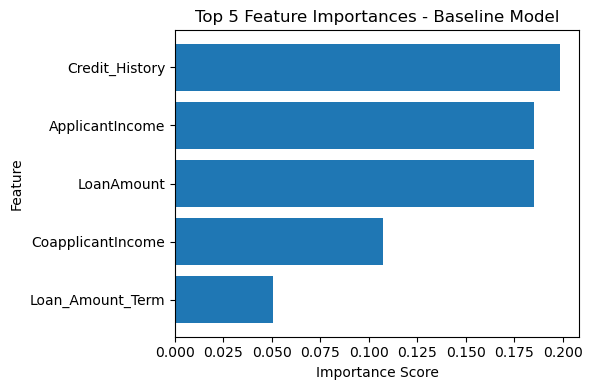

In [18]:
b_importance = pd.DataFrame({'Feature': X_train.columns, 'Importance': b_model.feature_importances_})
b_importance = b_importance.sort_values(by = 'Importance', ascending = False).head(5)
plt.figure(figsize = (6, 4))
plt.barh(b_importance['Feature'], b_importance['Importance'])
plt.title('Top 5 Feature Importances - Baseline Model')
plt.xlabel('Importance Score'); plt.ylabel('Feature')
plt.gca().invert_yaxis(); plt.tight_layout()
plt.show()

# **Hyperparameter Tuning**

## **Task 10**
- Define suitable values for `n_estimators`, `max_depth`, `min_samples_split`, `min_samples_leaf`, and `class_weight` that will be tested during Random Forest hyperparameter tuning

In [19]:
parameter_grid = {'n_estimators': [100, 200], 'max_depth': [None, 5], 
                  'min_samples_split': [2, 5, 7], 'min_samples_leaf': [1, 2, 4], 
                  'class_weight': [None, 'balanced']}
print(parameter_grid)

{'n_estimators': [100, 200], 'max_depth': [None, 5], 'min_samples_split': [2, 5, 7], 'min_samples_leaf': [1, 2, 4], 'class_weight': [None, 'balanced']}


## **Task 11**
- Select an appropriate scoring metric according to the problem statement and model objective
- Tune the Random Forest model using five-fold cross-validation and the selected scoring metric
- Display the best hyperparameters, best cross-validation score, and best trained model selected by GridSearchCV

In [20]:
random_forest_model = RandomForestClassifier(random_state = 42)
grid_search = GridSearchCV(estimator = random_forest_model, param_grid = parameter_grid, scoring = 'f1', cv = 5, n_jobs = 1 , verbose=10)
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 72 candidates, totalling 360 fits
[CV 1/5; 1/72] START class_weight=None, max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100
[CV 1/5; 1/72] END class_weight=None, max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100;, score=0.938 total time=   0.0s
[CV 2/5; 1/72] START class_weight=None, max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100
[CV 2/5; 1/72] END class_weight=None, max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100;, score=0.842 total time=   0.1s
[CV 3/5; 1/72] START class_weight=None, max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100
[CV 3/5; 1/72] END class_weight=None, max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100;, score=0.814 total time=   0.1s
[CV 4/5; 1/72] START class_weight=None, max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100
[CV 4/5; 1/72] END class_weight=None, max_depth

,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'class_weight': [None, 'balanced'], 'max_depth': [None, 5], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,scoring,'f1'
,n_jobs,1
,refit,True
,cv,5
,verbose,10
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,100


In [21]:
print('Best Hyperparameters:'); print(grid_search.best_params_)
print('\nBest Cross-Validation:'); print(round(grid_search.best_score_, 3))
print('\nBest Tuned Model:'); print(grid_search.best_estimator_)

Best Hyperparameters:
{'class_weight': None, 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 7, 'n_estimators': 100}

Best Cross-Validation:
0.874

Best Tuned Model:
RandomForestClassifier(max_depth=5, min_samples_split=7, random_state=42)


# **Tuned Model Evaluation and Interpretation**

## **Task 12**
- Store the best tuned Random Forest model and generate predictions and probability scores for the training and testing datasets
- Calculate the training and testing performance gap using the selected evaluation metric

In [22]:
f_model = grid_search.best_estimator_; f_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,5
,min_samples_split,7
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [23]:
f_train_pred = f_model.predict(X_train); f_test_pred = f_model.predict(X_test)
f_train_prob = f_model.predict_proba(X_train)[:, 1] ; f_test_prob = f_model.predict_proba(X_test)[:, 1]
f_train_f1 = f1_score(y_train, f_train_pred); f_test_f1 = f1_score(y_test, f_test_pred)

In [24]:
f_f1_gap = f_train_f1 - f_test_f1
print('F1-Score Gap:', round(f_f1_gap, 3))

F1-Score Gap: -0.003


## **Task 13**
- Display sample loan applications with their actual and tuned-model predicted labels

In [25]:
f_pred_df = X_test_original.copy()
f_pred_df['Actual Loan Status'] = y_test
f_pred_df['Predicted Loan Status'] = pd.Series(f_test_pred, index = y_test.index)
f_pred_df.sample(10, random_state = 42)

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Actual Loan Status,Predicted Loan Status
340,Male,No,0,Graduate,No,3750,0.0,100,360,1,Urban,1,1
286,Male,Yes,0,Graduate,No,19730,5266.0,570,360,1,Rural,0,1
6,Male,Yes,3+,Graduate,No,3036,2504.0,158,360,0,Semiurban,0,0
192,Male,Yes,1,Not Graduate,No,6608,0.0,137,180,1,Urban,1,1
322,Male,Yes,0,Not Graduate,No,2253,2033.0,110,360,1,Rural,1,1
327,Male,Yes,0,Graduate,No,1025,2773.0,112,360,1,Rural,1,1
288,Male,Yes,2,Graduate,No,5185,0.0,155,360,1,Semiurban,1,1
338,Male,No,0,Graduate,No,6500,0.0,105,360,0,Rural,0,0
189,Male,Yes,0,Not Graduate,No,3406,4417.0,123,360,1,Semiurban,1,1
20,Male,Yes,0,Graduate,No,2799,2253.0,122,360,1,Semiurban,1,1


## **Task 14**
- Create confusion matrices to compare the actual and predicted classes for the tuned model’s training and testing sets

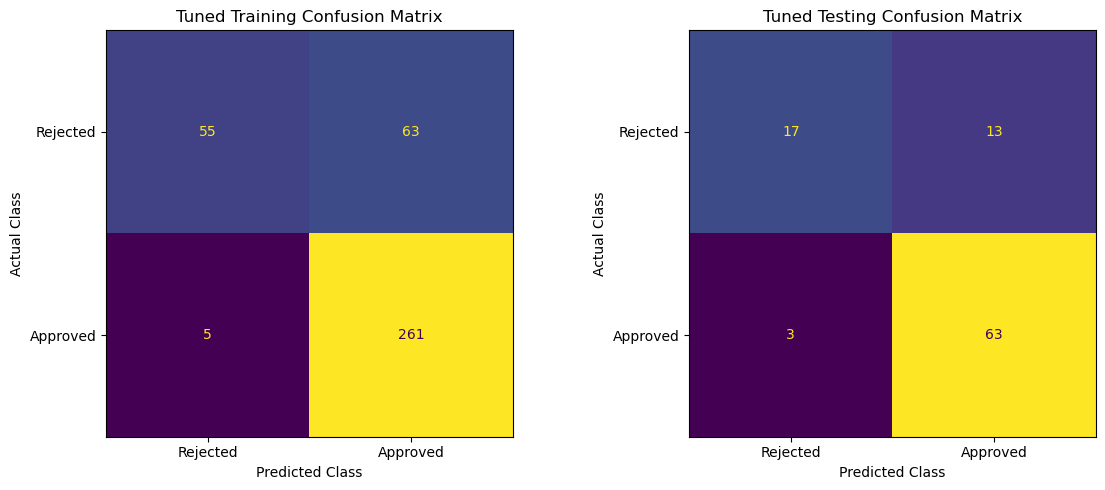

In [26]:
f_train_cm = confusion_matrix(y_train, f_train_pred); f_test_cm = confusion_matrix(y_test, f_test_pred)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay(confusion_matrix=f_train_cm, display_labels = ['Rejected', 'Approved']).plot(ax=axes[0], colorbar=False)
axes[0].set_title('Tuned Training Confusion Matrix')
axes[0].set_xlabel('Predicted Class'); axes[0].set_ylabel('Actual Class')
ConfusionMatrixDisplay(confusion_matrix=f_test_cm, display_labels = ['Rejected', 'Approved']).plot(ax=axes[1], colorbar=False)
axes[1].set_title('Tuned Testing Confusion Matrix')
axes[1].set_xlabel('Predicted Class'); axes[1].set_ylabel('Actual Class')
plt.tight_layout()
plt.show()

## **Task 15**
- Evaluate the tuned Random Forest model using accuracy, precision, recall, F1-score, and ROC-AUC

In [27]:
f_train_accuracy = accuracy_score(y_train, f_train_pred)
f_train_precision = precision_score(y_train, f_train_pred)
f_train_recall = recall_score(y_train, f_train_pred)
f_train_roc_auc = roc_auc_score(y_train, f_train_prob)
f_test_accuracy = accuracy_score(y_test, f_test_pred)
f_test_precision = precision_score(y_test, f_test_pred)
f_test_recall = recall_score(y_test, f_test_pred)
f_test_roc_auc = roc_auc_score(y_test, f_test_prob)

print('Tuned Model Training Metrics')
print('Accuracy:', round(f_train_accuracy, 3))
print('Precision:', round(f_train_precision, 3))
print('Recall:', round(f_train_recall, 3))
print('F1-Score:', round(f_train_f1, 3))
print('ROC-AUC:', round(f_train_roc_auc, 3))
print('\nTuned Model Testing Metrics')
print('Accuracy:', round(f_test_accuracy, 3))
print('Precision:', round(f_test_precision, 3))
print('Recall:', round(f_test_recall, 3))
print('F1-Score:', round(f_test_f1, 3))
print('ROC-AUC:', round(f_test_roc_auc, 3))

Tuned Model Training Metrics
Accuracy: 0.823
Precision: 0.806
Recall: 0.981
F1-Score: 0.885
ROC-AUC: 0.906

Tuned Model Testing Metrics
Accuracy: 0.833
Precision: 0.829
Recall: 0.955
F1-Score: 0.887
ROC-AUC: 0.81


## **Task 16**
- Plot the training and testing ROC curves for the baseline and tuned models

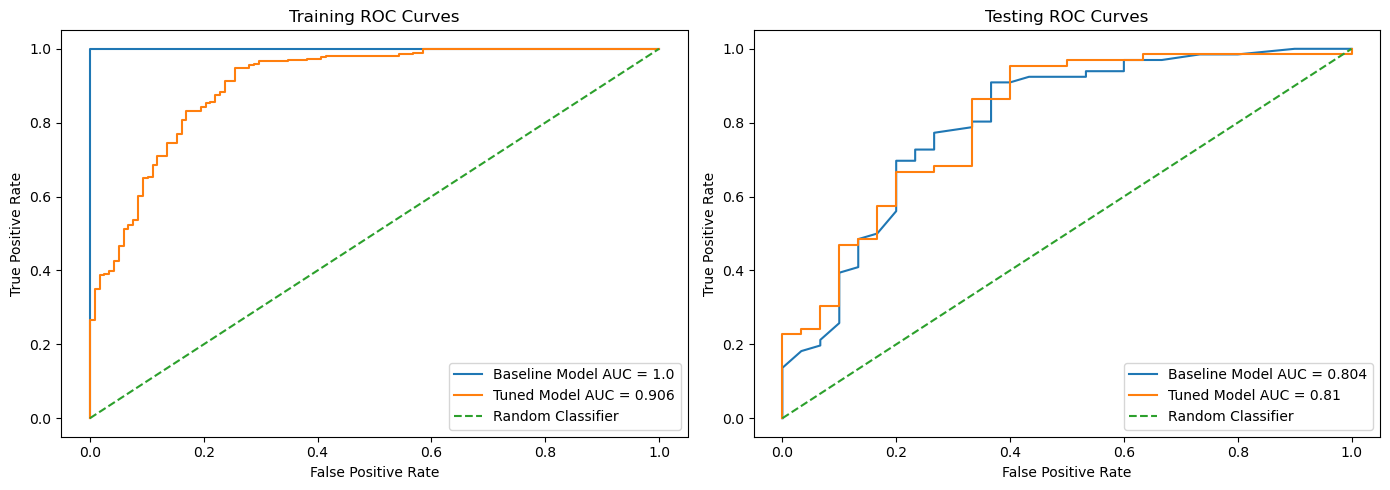

In [28]:
b_train_fpr, b_train_tpr, _ = roc_curve(y_train, b_train_prob); b_test_fpr, b_test_tpr, _ = roc_curve(y_test, b_test_prob)
f_train_fpr, f_train_tpr, _ = roc_curve(y_train, f_train_prob); f_test_fpr, f_test_tpr, _ = roc_curve(y_test, f_test_prob)
fig, axes = plt.subplots(1, 2, figsize = (14, 5))
axes[0].plot(b_train_fpr, b_train_tpr, label = 'Baseline Model AUC = ' + str(round(b_train_roc_auc, 3)))
axes[0].plot(f_train_fpr, f_train_tpr, label = 'Tuned Model AUC = ' + str(round(f_train_roc_auc, 3)))
axes[0].plot([0, 1], [0, 1], linestyle = '--', label = 'Random Classifier')
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('Training ROC Curves')
axes[0].legend()
axes[1].plot(b_test_fpr, b_test_tpr, label = 'Baseline Model AUC = ' + str(round(b_test_roc_auc, 3)))
axes[1].plot(f_test_fpr, f_test_tpr, label = 'Tuned Model AUC = ' + str(round(f_test_roc_auc, 3)))
axes[1].plot([0, 1], [0, 1], linestyle = '--', label = 'Random Classifier')
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Testing ROC Curves')
axes[1].legend()
plt.tight_layout()
plt.show()

## **Task 17**
- Compare accuracy, precision, recall, F1-score, and ROC-AUC for the baseline and tuned Random Forest models and also compare the training and testing performance gaps using the selected primary evaluation metric

In [29]:
model_comparison = pd.DataFrame({'Model': ['Baseline Model', 'Tuned Model'],
                                 'Training Accuracy': [b_train_accuracy, f_train_accuracy],
                                 'Testing Accuracy': [b_test_accuracy, f_test_accuracy],
                                 'Training Precision': [b_train_precision, f_train_precision],
                                 'Testing Precision': [b_test_precision, f_test_precision],
                                 'Training Recall': [b_train_recall, f_train_recall],
                                 'Testing Recall': [b_test_recall, f_test_recall],
                                 'Training F1-Score': [b_train_f1, f_train_f1],
                                 'Testing F1-Score': [b_test_f1, f_test_f1],
                                 'Training ROC-AUC': [b_train_roc_auc, f_train_roc_auc],
                                 'Testing ROC-AUC': [b_test_roc_auc, f_test_roc_auc],
                                 'F1-Score Gap': [b_f1_gap, f_f1_gap]})
model_comparison.round(3)

,Model,Training Accuracy,Testing Accuracy,Training Precision,Testing Precision,Training Recall,Testing Recall,Training F1-Score,Testing F1-Score,Training ROC-AUC,Testing ROC-AUC,F1-Score Gap
0,Baseline Model,1.000,0.792,1.000,0.838,1.000,0.864,1.000,0.851,1.000,0.804,0.149
1,Tuned Model,0.823,0.833,0.806,0.829,0.981,0.955,0.885,0.887,0.906,0.810,-0.003
